In [63]:
# Import required libraries
from sqlalchemy import create_engine

import pandas as pd
import matplotlib.pyplot as plt

engine = create_engine(
    "mssql+pyodbc://localhost\\SQLEXPRESS/JomatoDB?"
    "driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)
# Connect to SQL Server and load the data
df = pd.read_sql("SELECT * FROM Jomato", engine)
# Display first 5 records
df.head()

,OrderId,RestaurantName,RestaurantType,Rating,No_of_Rating,AverageCost,OnlineOrder,TableBooking,CuisinesType,Area,LocalAddress,Delivery_time
0,1,L-81 Cafe,Quick Bites,3.9,48,400.0,True,False,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR,59
1,2,refuel,Cafe,3.7,37,400.0,True,False,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road,56
2,3,Biryani Central,Casual Dining,2.7,135,550.0,True,False,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli,50
3,4,The Bbq,Casual Dining,2.8,40,700.0,True,False,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur,57
4,5,The Bbq,"Takeaway, Delivery",3.4,37,200.0,False,False,"Mughlai, Biryani, Chinese, North Indian",Whitefield,Whitefield,63


In [64]:
# Check the size of the dataset (rows and columns)
df.shape

(7104, 12)

In [65]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7104 entries, 0 to 7103
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderId         7104 non-null   int64  
 1   RestaurantName  7104 non-null   object 
 2   RestaurantType  7104 non-null   object 
 3   Rating          7036 non-null   float64
 4   No_of_Rating    7104 non-null   int64  
 5   AverageCost     7047 non-null   float64
 6   OnlineOrder     7104 non-null   bool   
 7   TableBooking    7104 non-null   bool   
 8   CuisinesType    7104 non-null   object 
 9   Area            7104 non-null   object 
 10  LocalAddress    7104 non-null   object 
 11  Delivery_time   7104 non-null   int64  
dtypes: bool(2), float64(2), int64(3), object(5)
memory usage: 569.0+ KB


In [66]:
# Check missing values in each column
df.isnull().sum()

OrderId            0
RestaurantName     0
RestaurantType     0
Rating            68
No_of_Rating       0
AverageCost       57
OnlineOrder        0
TableBooking       0
CuisinesType       0
Area               0
LocalAddress       0
Delivery_time      0
dtype: int64

In [67]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

In [68]:
# Check the percentage of missing values in each column.
# This helps us decide the most appropriate method to handle missing values,
# such as using the mean, median, mode, or removing rows/columns.
(df.isnull().sum() / len(df)) * 100

OrderId           0.000000
RestaurantName    0.000000
RestaurantType    0.000000
Rating            0.957207
No_of_Rating      0.000000
AverageCost       0.802365
OnlineOrder       0.000000
TableBooking      0.000000
CuisinesType      0.000000
Area              0.000000
LocalAddress      0.000000
Delivery_time     0.000000
dtype: float64

In [69]:
df["Rating"].max()
#it is valid value of max in dataset

4.900000095367432

In [70]:
round(df["Rating"].min(), 2)
#it is valid value of min in dataset

1.8

In [71]:
df.isnull().sum()

OrderId            0
RestaurantName     0
RestaurantType     0
Rating            68
No_of_Rating       0
AverageCost       57
OnlineOrder        0
TableBooking       0
CuisinesType       0
Area               0
LocalAddress       0
Delivery_time      0
dtype: int64

In [72]:
# I fill the null value of Rating with median
df["Rating"]=df["Rating"].fillna(df["Rating"].median())

In [73]:
# removed the outlier in ranking columns
df.isnull().sum()

OrderId            0
RestaurantName     0
RestaurantType     0
Rating             0
No_of_Rating       0
AverageCost       57
OnlineOrder        0
TableBooking       0
CuisinesType       0
Area               0
LocalAddress       0
Delivery_time      0
dtype: int64

In [74]:
# I checked that the data is invald or not with the help of max and min value 

In [75]:
df["AverageCost"].max()

6000.0

In [76]:
df["AverageCost"].min()

40.0

In [77]:
df["AverageCost"]=df["AverageCost"].fillna(df["AverageCost"].median())

In [78]:
df.isnull().sum()

OrderId           0
RestaurantName    0
RestaurantType    0
Rating            0
No_of_Rating      0
AverageCost       0
OnlineOrder       0
TableBooking      0
CuisinesType      0
Area              0
LocalAddress      0
Delivery_time     0
dtype: int64

In [79]:
df

,OrderId,RestaurantName,RestaurantType,Rating,No_of_Rating,AverageCost,OnlineOrder,TableBooking,CuisinesType,Area,LocalAddress,Delivery_time
0,1,L-81 Cafe,Quick Bites,3.9,48,400.0,True,False,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR,59
1,2,refuel,Cafe,3.7,37,400.0,True,False,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road,56
2,3,Biryani Central,Casual Dining,2.7,135,550.0,True,False,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli,50
3,4,The Bbq,Casual Dining,2.8,40,700.0,True,False,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur,57
4,5,The Bbq,"Takeaway, Delivery",3.4,37,200.0,False,False,"Mughlai, Biryani, Chinese, North Indian",Whitefield,Whitefield,63
...,...,...,...,...,...,...,...,...,...,...,...,...
7099,7100,Zoey's,Cafe,4.3,894,600.0,True,False,"Cafe, Italian, Continental, Burger",Bellandur,Sarjapur Road,34
7100,7101,ZOROY Luxury Chocolate,Dessert Parlor,4.0,68,250.0,True,False,Desserts,Brigade Road,Church Street,39
7101,7102,Zu's Doner Kebaps,"Takeaway, Delivery",3.7,33,350.0,False,False,"Turkish, Fast Food, Biryani, Chinese",Malleshwaram,RT Nagar,52
7102,7103,Zyara,Casual Dining,3.8,191,650.0,True,False,"North Indian, Mughlai, Chinese",Kammanahalli,HBR Layout,54


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7104 entries, 0 to 7103
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderId         7104 non-null   int64  
 1   RestaurantName  7104 non-null   object 
 2   RestaurantType  7104 non-null   object 
 3   Rating          7104 non-null   float64
 4   No_of_Rating    7104 non-null   int64  
 5   AverageCost     7104 non-null   float64
 6   OnlineOrder     7104 non-null   bool   
 7   TableBooking    7104 non-null   bool   
 8   CuisinesType    7104 non-null   object 
 9   Area            7104 non-null   object 
 10  LocalAddress    7104 non-null   object 
 11  Delivery_time   7104 non-null   int64  
dtypes: bool(2), float64(2), int64(3), object(5)
memory usage: 569.0+ KB


In [81]:
df.describe()

,OrderId,Rating,No_of_Rating,AverageCost,Delivery_time
count,7104.000000,7104.000000,7104.000000,7104.000000,7104.000000
mean,3552.500000,3.514133,188.946650,539.208756,54.644426
std,2050.892489,0.461059,592.208798,461.226235,14.262477
min,1.000000,1.800000,1.000000,40.000000,20.000000
25%,1776.750000,3.200000,16.000000,300.000000,45.000000
50%,3552.500000,3.500000,40.000000,400.000000,53.000000
75%,5328.250000,3.800000,128.000000,600.000000,64.000000
max,7104.000000,4.900000,16345.000000,6000.000000,109.000000


In [82]:
df.to_csv("Zomato.csv",index=False)

In [83]:
import os
os.getcwd()

'C:\\Users\\ASUS'

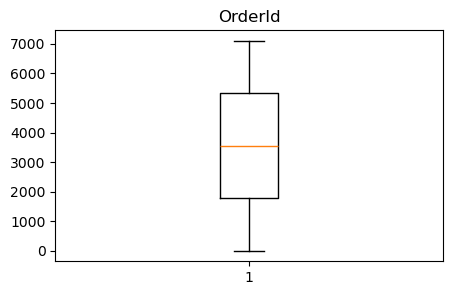

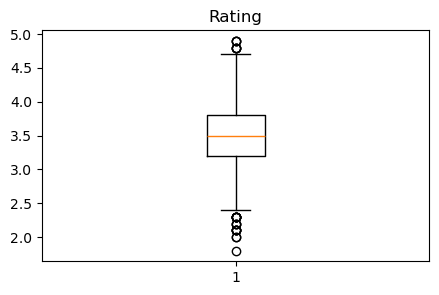

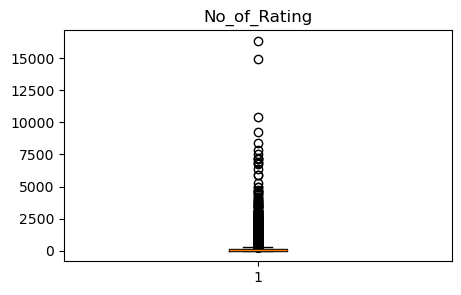

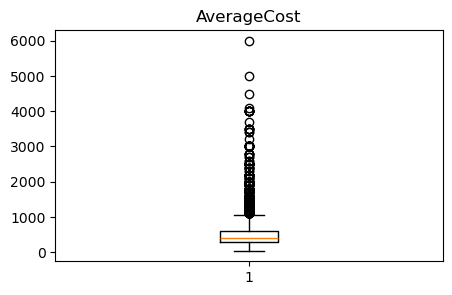

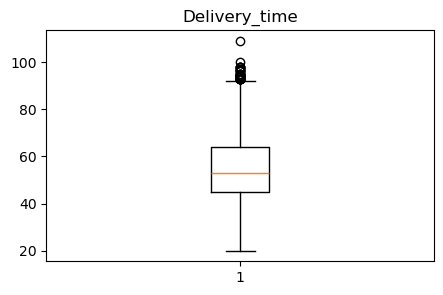

In [84]:
for i in df.columns:
    if df[i].dtype != "object" and df[i].dtype != "bool":
        plt.figure(figsize=(5,3))
        plt.boxplot(df[i])
        plt.title(i)
        plt.show()

In [85]:
df

,OrderId,RestaurantName,RestaurantType,Rating,No_of_Rating,AverageCost,OnlineOrder,TableBooking,CuisinesType,Area,LocalAddress,Delivery_time
0,1,L-81 Cafe,Quick Bites,3.9,48,400.0,True,False,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR,59
1,2,refuel,Cafe,3.7,37,400.0,True,False,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road,56
2,3,Biryani Central,Casual Dining,2.7,135,550.0,True,False,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli,50
3,4,The Bbq,Casual Dining,2.8,40,700.0,True,False,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur,57
4,5,The Bbq,"Takeaway, Delivery",3.4,37,200.0,False,False,"Mughlai, Biryani, Chinese, North Indian",Whitefield,Whitefield,63
...,...,...,...,...,...,...,...,...,...,...,...,...
7099,7100,Zoey's,Cafe,4.3,894,600.0,True,False,"Cafe, Italian, Continental, Burger",Bellandur,Sarjapur Road,34
7100,7101,ZOROY Luxury Chocolate,Dessert Parlor,4.0,68,250.0,True,False,Desserts,Brigade Road,Church Street,39
7101,7102,Zu's Doner Kebaps,"Takeaway, Delivery",3.7,33,350.0,False,False,"Turkish, Fast Food, Biryani, Chinese",Malleshwaram,RT Nagar,52
7102,7103,Zyara,Casual Dining,3.8,191,650.0,True,False,"North Indian, Mughlai, Chinese",Kammanahalli,HBR Layout,54


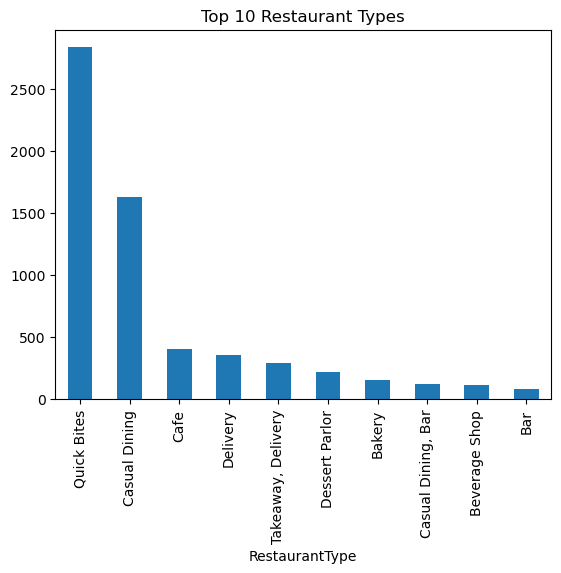

In [86]:
# Count the number of restaurants for each restaurant type and plot the top 10 types
df["RestaurantType"].value_counts().head(10).plot(kind="bar")

# Add a title to the chart
plt.title("Top 10 Restaurant Types")

# Rotate x-axis labels by 90 degrees for better readability
plt.xticks(rotation=90)

# Display the chart
plt.show()

In [87]:
# Calculate the total number of online orders for each restaurant type
df.groupby("RestaurantType")["OnlineOrder"].sum().sort_values(ascending=False)

RestaurantType
Quick Bites                  1512
Casual Dining                 952
Delivery                      224
Cafe                          219
Takeaway, Delivery            183
                             ... 
Bar, Lounge                     0
Fine Dining, Microbrewery       0
Lounge, Microbrewery            0
Lounge, Cafe                    0
Bar, Pub                        0
Name: OnlineOrder, Length: 81, dtype: int64

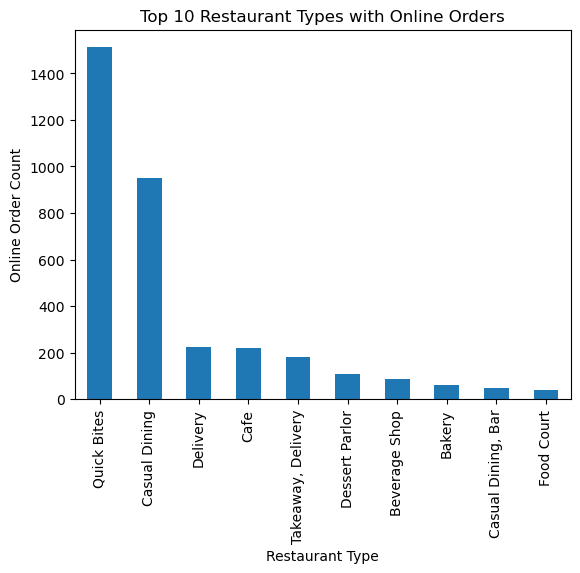

In [88]:
# Filter True online orders, group by RestaurantType,
# count them, sort, take top 10 and create bar chart

df[df["OnlineOrder"] == True].groupby("RestaurantType")["OnlineOrder"].sum().sort_values(ascending=False).head(10).plot(kind="bar")

plt.xlabel("Restaurant Type")
plt.ylabel("Online Order Count")
plt.title("Top 10 Restaurant Types with Online Orders")
plt.show()

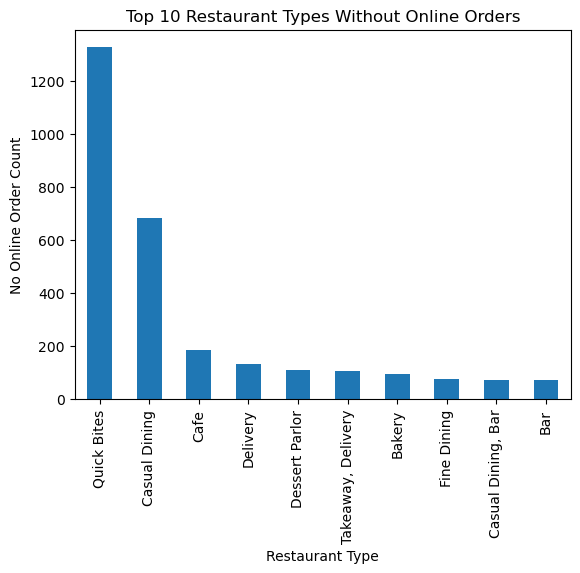

In [89]:
# Filter only restaurants where OnlineOrder is False (No)
result = df[df["OnlineOrder"] == False]

# Group the filtered data by RestaurantType
# Then count the number of restaurants in each type
result = result.groupby("RestaurantType")["OnlineOrder"].size()

# Sort restaurant types from highest count to lowest count
result = result.sort_values(ascending=False)

# Select the top 10 restaurant types
result = result.head(10)

# Create a bar chart
result.plot(kind="bar")

# Set the X-axis label
plt.xlabel("Restaurant Type")

# Set the Y-axis label
plt.ylabel("No Online Order Count")

# Set the chart title
plt.title("Top 10 Restaurant Types Without Online Orders")

# Display the chart
plt.show()

In [90]:
# Calculate the average (mean) delivery time for each area
round(df.groupby("Area")["Delivery_time"].mean().sort_values(ascending=False).head(10),2)

Area
Koramangala 7th Block    61.36
MG Road                  59.97
Church Street            58.01
Old Airport Road         56.91
Basavanagudi             55.99
JP Nagar                 55.75
Malleshwaram             55.45
Bannerghatta Road        55.44
Indiranagar              55.42
New BEL Road             55.36
Name: Delivery_time, dtype: float64

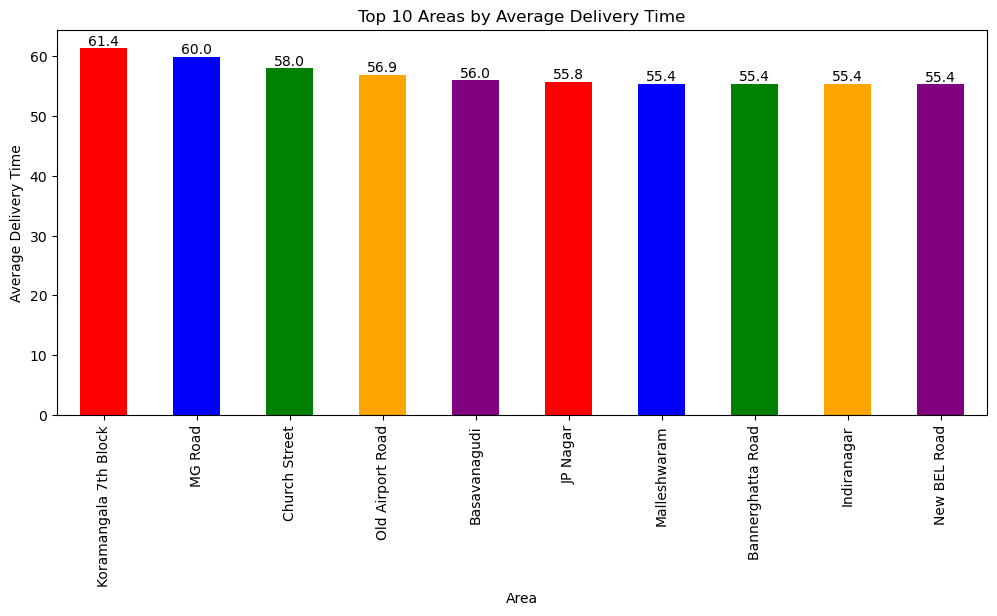

In [91]:
# Set the figure size
plt.figure(figsize=(12, 5))

# Calculate the average (mean) delivery time for each area
# Sort the results in descending order so the highest delivery times come first
# Select only the top 10 areas
result = (
    df.groupby("Area")["Delivery_time"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

# Create a bar chart to visualize the average delivery time
# Apply different colors to the bars
ax = result.plot(
    kind="bar",
    color=["red", "blue", "green", "orange", "purple"]
)

# Add the average delivery time value above each bar
for i, value in enumerate(result):

    # Display the value on top of each bar
    ax.text(
        i,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

# Set the chart title
plt.title("Top 10 Areas by Average Delivery Time")

# Set the x-axis label
plt.xlabel("Area")

# Set the y-axis label
plt.ylabel("Average Delivery Time")

# Rotate the area names by 90 degrees for better readability
plt.xticks(rotation=90)

# Display the chart
plt.show()

In [92]:

# Calculate the average delivery time for each restaurant type
# Sort the results from highest to lowest
# Select the top 10 restaurant types
# Round the average delivery time to 2 decimal places

result = round(
    df.groupby("RestaurantType")["Delivery_time"]
      .mean()
      .sort_values(ascending=False)
      .head(10),
    2
)

result

RestaurantType
Food Court, Dessert Parlor       86.00
Club, Casual Dining              80.00
Bhojanalya                       76.00
Fine Dining, Microbrewery        75.00
Pub, Bar                         66.00
Dessert Parlor, Cafe             63.67
Dhaba                            61.71
Cafe, Quick Bites                61.09
Pub, Microbrewery                60.50
Beverage Shop, Dessert Parlor    60.17
Name: Delivery_time, dtype: float64

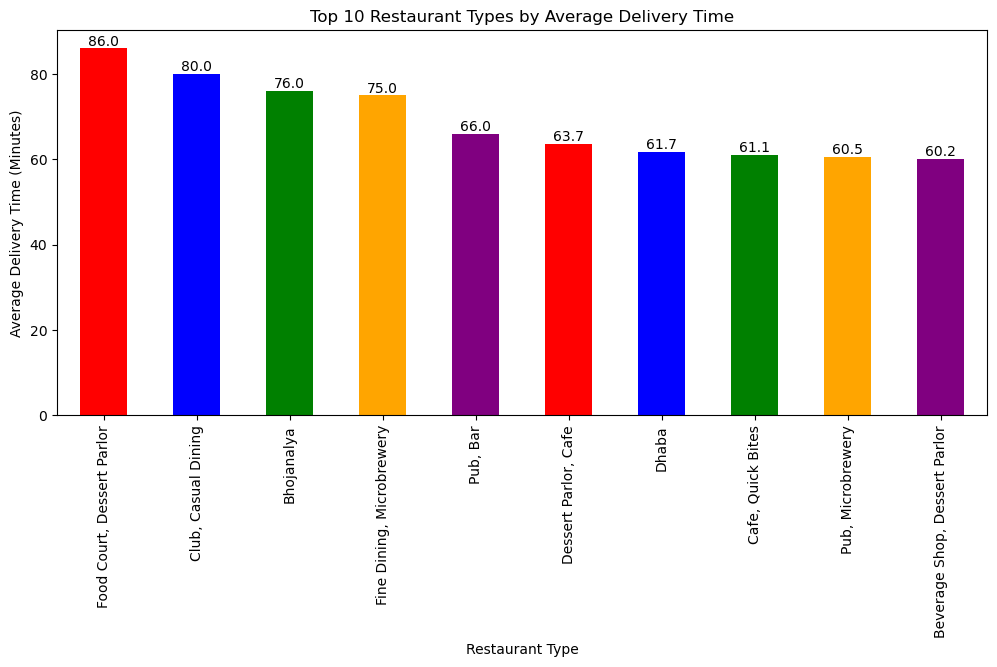

In [93]:
# Set the figure size
plt.figure(figsize=(12, 5))

# Create a bar chart using the result values
# Apply different colors to the bars
ax = result.plot(
    kind="bar",
    color=["red", "blue", "green", "orange", "purple"]
)

# Add the value of each bar above the bar
for i, value in enumerate(result):

    # Display the value with one decimal place
    ax.text(
        i,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )
    # Chart title
plt.title("Top 10 Restaurant Types by Average Delivery Time")

# X-axis
plt.xlabel("Restaurant Type")

# Y-axis
plt.ylabel("Average Delivery Time (Minutes)")
# Rotate restaurant type names
plt.xticks(rotation=90)

plt.show()

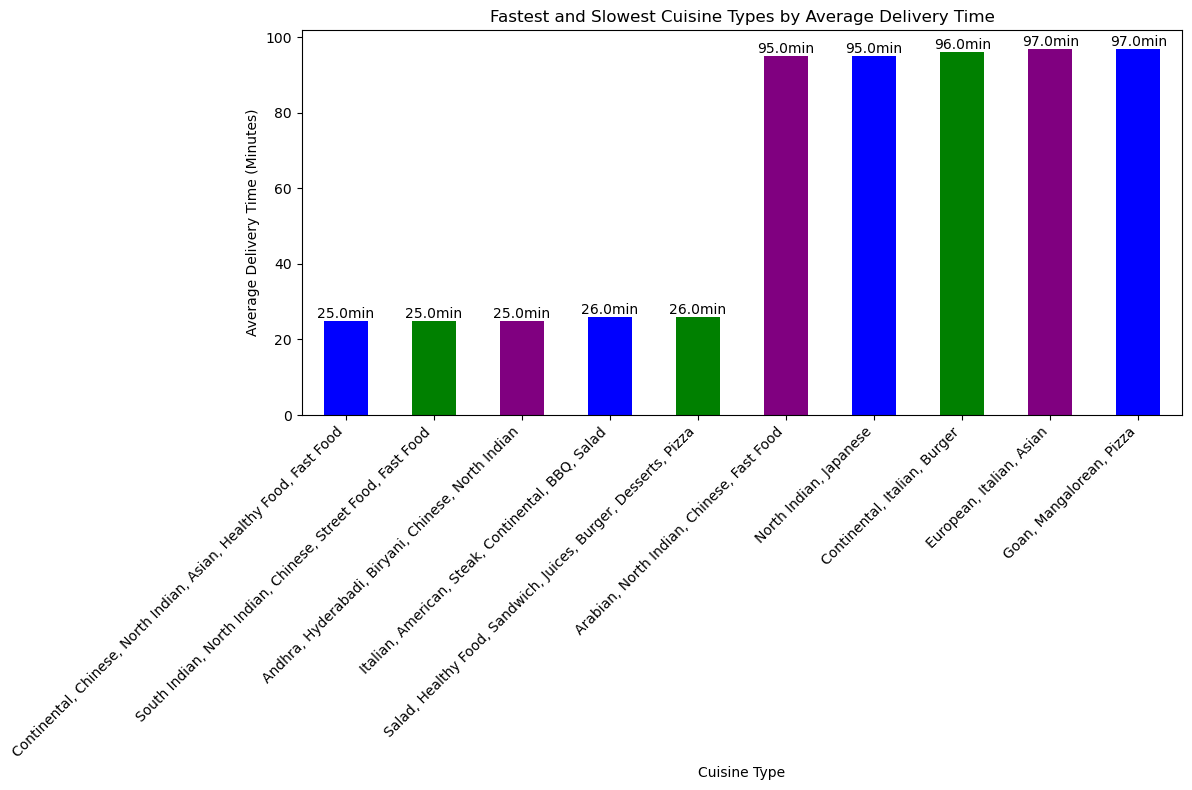

In [94]:
# Calculate the average delivery time for each cuisine type
result = (
    df.groupby("CuisinesType")["Delivery_time"]
      .mean()
      .sort_values()
)

# Select the 5 fastest cuisine types
fastest = result.head(5)

# Select the 5 slowest cuisine types
slowest = result.tail(5)

# Combine the fastest and slowest cuisine types
final_result = pd.concat([fastest, slowest])

# Create the figure
plt.figure(figsize=(12, 8))

# Create the bar chart
ax = final_result.plot(kind="bar", color=["blue", "green", "purple"])

# Add average delivery time above each bar
for i, value in enumerate(final_result):
    ax.text(
        i,
        value,
        f"{value:.1f}min",
        ha="center",
        va="bottom"
    )

# Set the chart title
plt.title("Fastest and Slowest Cuisine Types by Average Delivery Time")

# Set the X-axis label
plt.xlabel("Cuisine Type")

# Set the Y-axis label
plt.ylabel("Average Delivery Time (Minutes)")

# Rotate cuisine names for readability
plt.xticks(rotation=45, ha="right")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

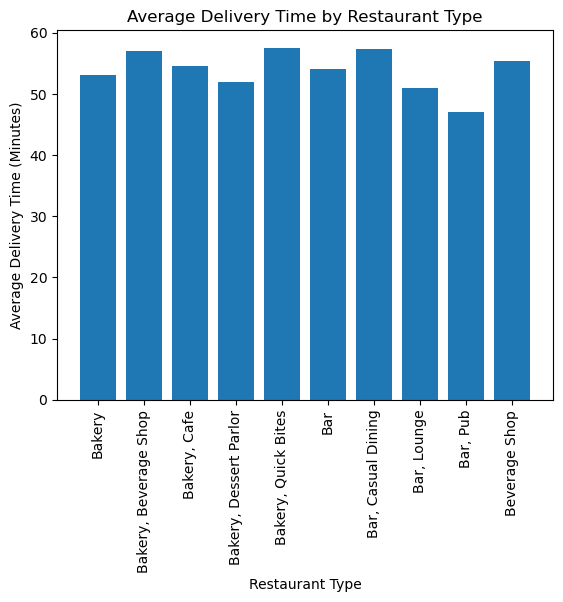

In [95]:
# Calculate average delivery time for each restaurant type
result = (
    df.groupby("RestaurantType")["Delivery_time"]
      .mean()
      .reset_index()
      .head(10)
)

# Create bar chart
plt.bar(
    result["RestaurantType"],
    result["Delivery_time"]
)

# X-axis label
plt.xlabel("Restaurant Type")

# Y-axis label
plt.ylabel("Average Delivery Time (Minutes)")

# Chart title
plt.title("Average Delivery Time by Restaurant Type")

# Rotate restaurant type names for better readability
plt.xticks(rotation=90)

# Display the chart
plt.show()

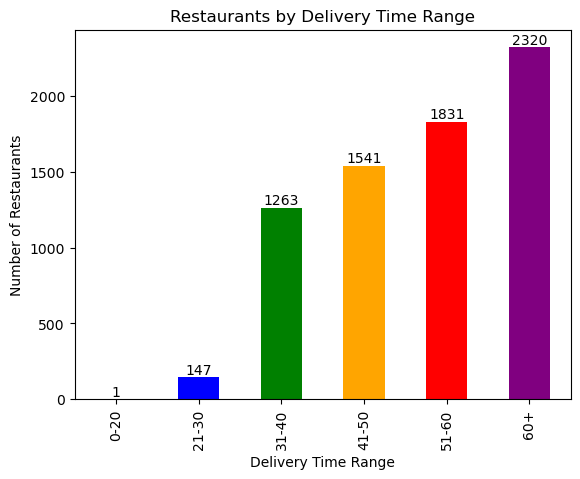

In [96]:
# Define delivery-time ranges
bins = [0, 20, 30, 40, 50, 60, 100]

# Give names to each range
labels = ['0-20', '21-30', '31-40', '41-50', '51-60', '60+']

# Convert Delivery_time into categories/ranges
df['Range'] = pd.cut(
    df['Delivery_time'],
    bins=bins,
    labels=labels
)

# Count how many restaurants are in each delivery-time range
final_result = df['Range'].value_counts().sort_index()

# Create column chart
ax = final_result.plot(
    kind='bar',
    color=["yellow", "blue", "green", "orange", "red", "purple"]
)

# X-axis label
plt.xlabel('Delivery Time Range')

# Y-axis label
plt.ylabel('Number of Restaurants')

# Chart title
plt.title('Restaurants by Delivery Time Range')

# Add count value on top of each column
for i, value in enumerate(final_result):
    ax.text(
        i,
        value,
        f"{value}",
        ha="center",
        va="bottom"
    )

# Display the chart
plt.show()

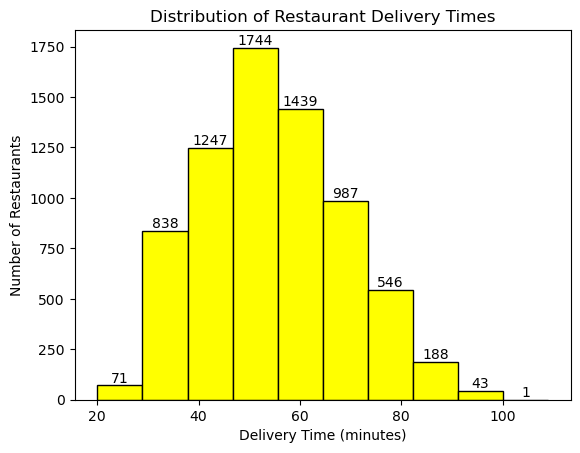

In [97]:
# Create histogram
n, bins, patches = plt.hist(
    df['Delivery_time'],
    bins=10,
    color="yellow",
    edgecolor="black"
)

# X-axis label
plt.xlabel('Delivery Time (minutes)')

# Y-axis label
plt.ylabel('Number of Restaurants')

# Chart title
plt.title('Distribution of Restaurant Delivery Times')


# Add count on top of each bar
for i, value in enumerate(n):
    plt.text(
        bins[i] + (bins[i+1] - bins[i]) / 2,
        value,
        f"{int(value)}",
        ha="center",
        va="bottom"
    )

# Show chart
plt.show()

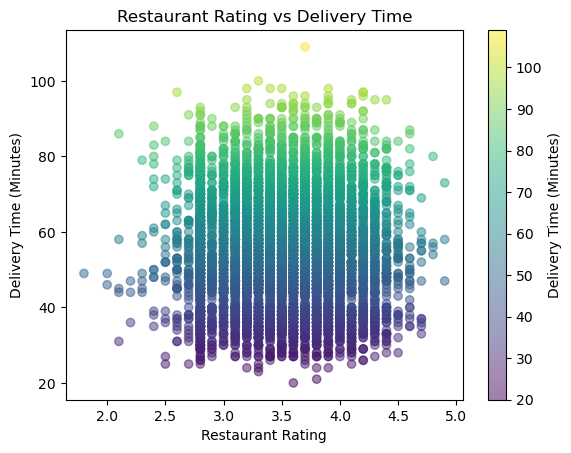

In [103]:
#Does higher restaurant rating relate to faster delivery time?
# Create scatter plot
# X-axis = Restaurant Rating
# Y-axis = Delivery Time
# Color = Delivery Time
plt.scatter(
    df['Rating'],
    df['Delivery_time'],
    c=df['Delivery_time'],
    cmap='viridis',
    alpha=0.5
)

# X-axis label
plt.xlabel('Restaurant Rating')

# Y-axis label
plt.ylabel('Delivery Time (Minutes)')

# Chart title
plt.title('Restaurant Rating vs Delivery Time')

# Add colorbar to show delivery-time color scale
plt.colorbar(label='Delivery Time (Minutes)')

# Display the chart
plt.show()

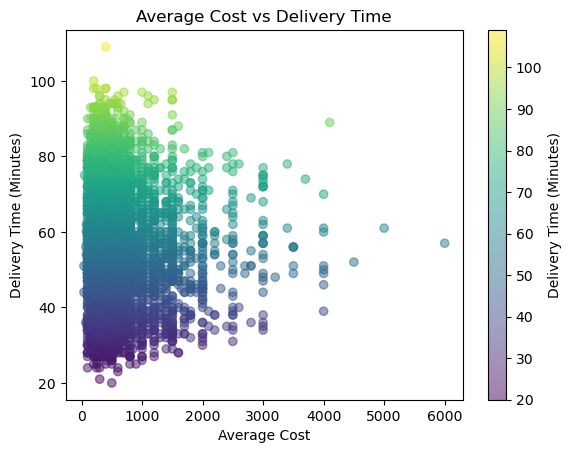

In [104]:
#Does average cost affect delivery time?
# Create scatter plot
# X-axis = Average Cost
# Y-axis = Delivery Time
# Color = Delivery Time
plt.scatter(
    df['AverageCost'],
    df['Delivery_time'],
    c=df['Delivery_time'],
    cmap='viridis',
    alpha=0.5
)

# X-axis label
plt.xlabel('Average Cost')

# Y-axis label
plt.ylabel('Delivery Time (Minutes)')

# Chart title
plt.title('Average Cost vs Delivery Time')

# Add colorbar to show delivery-time scale
plt.colorbar(label='Delivery Time (Minutes)')

# Display the chart
plt.show()
#The scatter plot shows no strong visible relationship between average cost and delivery time.
#Higher-cost restaurants do not necessarily have faster or slower delivery.

   OnlineOrder  Delivery_time
0        False      54.636364
1         True      54.651731


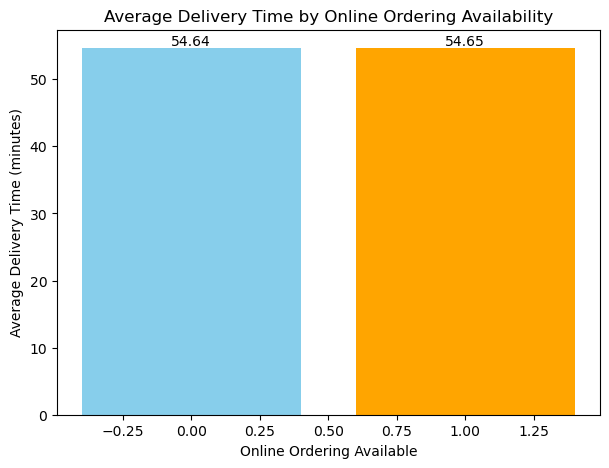

In [106]:
# Calculate average delivery time by online ordering availability
result = df.groupby('OnlineOrder')['Delivery_time'].mean().reset_index()

print(result)

# Bar chart
plt.figure(figsize=(7, 5))

bars = plt.bar(
    result['OnlineOrder'],
    result['Delivery_time'],
    color=['skyblue', 'orange']   # Multiple colors
)

plt.title('Average Delivery Time by Online Ordering Availability')
plt.xlabel('Online Ordering Available')
plt.ylabel('Average Delivery Time (minutes)')

# Add values on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center',
        va='bottom'
    )

plt.show()

                             Area  Restaurant_Count
0  Byresandra,Tavarekere,Madiwala               581
1               Bannerghatta Road               402
2                     Brookefield               347
3                     Indiranagar               343
4                    Brigade Road               322
5                    Malleshwaram               313
6                 Electronic City               275
7                    Kalyan Nagar               267
8                       Bellandur               258
9                    Banashankari               248


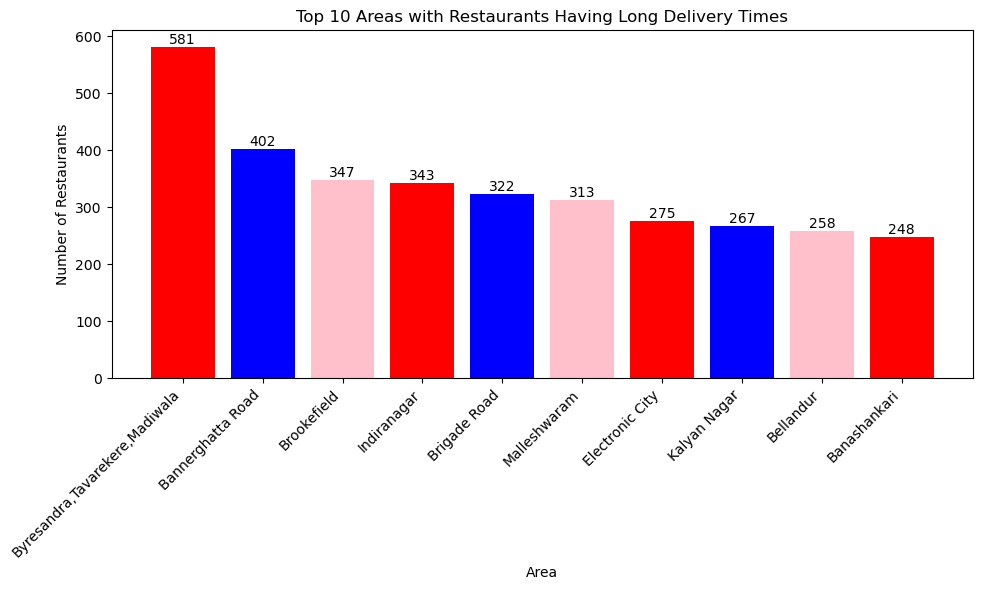

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter restaurants with long delivery time
long_delivery = df[df['Delivery_time'] > 45]

# Count restaurants by area
result = (
    long_delivery.groupby('Area')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='Restaurant_Count')
)

print(result)

# Bar chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    result['Area'],
    result['Restaurant_Count'],
    color=["red","blue","pink"]
)

plt.title('Top 10 Areas with Restaurants Having Long Delivery Times')
plt.xlabel('Area')
plt.ylabel('Number of Restaurants')

plt.xticks(rotation=45, ha='right')

# Add values on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

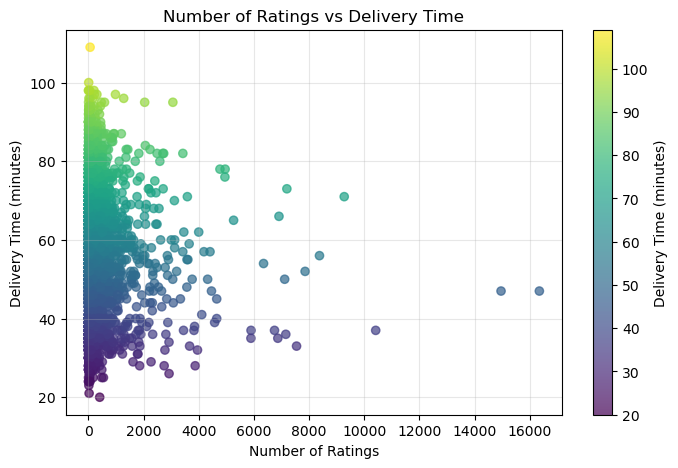

In [114]:
#Is the number of ratings related to delivery time?
# Remove missing values
result = df[['No_of_Rating', 'Delivery_time']].dropna()

# Scatter plot with multiple colors
plt.figure(figsize=(8, 5))

scatter = plt.scatter(
    result['No_of_Rating'],
    result['Delivery_time'],
    c=result['Delivery_time'],
    cmap='viridis',
    alpha=0.7
)

# Color scale
plt.colorbar(scatter, label='Delivery Time (minutes)')

plt.title('Number of Ratings vs Delivery Time')
plt.xlabel('Number of Ratings')
plt.ylabel('Delivery Time (minutes)')

plt.grid(alpha=0.3)
plt.show()